# Convolution, pooling, and what a filter learns

### The sliding window, the arithmetic of shapes, and the two properties everything later depends on

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | How a convolution is computed, written out in NumPy and checked against PyTorch; the one formula that gives every output shape; the parameter count of a real layer; three ways to downsample and how they differ; and how far back one output unit can see |
| **You should already know** | [Neural networks in PyTorch](../../07-neural-networks/03-the-same-net-in-pytorch/), and NumPy indexing |
| **Dataset** | Fashion-MNIST (28×28 greyscale). A handful of images, used as pictures to filter. Nothing is trained here |
| **Runtime** | Well under a minute on a laptop CPU |
| **Next** | [08-02 A CNN, layer by layer](../02-a-cnn-layer-by-layer/) |

---

This notebook is about the operation, not the network. Everything here happens
with fixed numbers I choose by hand, so that when the next notebook lets
gradient descent choose them instead, there is nothing left to be mysterious
about except the choosing.

## 1. The operation

A convolution takes a small grid of weights — the kernel, or filter — lays it
over a patch of the image, multiplies the overlapping numbers pairwise, and adds
them up. That sum is one pixel of the output. Then the kernel slides one step
along and the whole thing repeats until it has covered the image.

$$(I * K)(i, j) = \sum_{m=0}^{k-1}\sum_{n=0}^{k-1} I(i+m,\; j+n)\, K(m, n)$$

The result is a **feature map**: one number per position, saying how strongly
that patch of the image matched the pattern the kernel encodes.

One point of vocabulary, since it confuses people who arrive from signal
processing. The formula above is **cross-correlation**. A true convolution flips
the kernel in both directions first. Every deep learning library does the
unflipped version and calls it convolution anyway, and it makes no difference:
the weights are learned, so a library that flipped them would simply learn the
flipped kernel. I use the library convention throughout.

In [1]:
import sys
import pathlib
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0
torch.manual_seed(SEED)

print(f"torch {torch.__version__}, numpy {np.__version__}")

train_set = datasets.fashion_mnist(train=True)
CLASSES = ["T-shirt", "trouser", "pullover", "dress", "coat",
           "sandal", "shirt", "sneaker", "bag", "boot"]
print(f"{len(train_set):,} images available, 28x28 greyscale. No training in this notebook")

torch 2.11.0+cu128, numpy 2.4.6


60,000 images available, 28x28 greyscale. No training in this notebook


To see the arithmetic I need numbers small enough to read. So I take a 6×6 crop
from one garment — the crop where my chosen kernel has the most to say, rather
than six columns of background — round the pixel values to single digits, and
run one 3×3 kernel over it position by position.

In [2]:
IMAGE_INDEX = 9
sample_image, sample_label = train_set[IMAGE_INDEX]

kernel = np.array([[1., 0., -1.],
                   [1., 0., -1.],
                   [1., 0., -1.]])
kernel_t = torch.tensor(kernel, dtype=torch.float32).view(1, 1, 3, 3)

# crop where this kernel has something to say, so the demo is not six columns of
# flat background. Pixel values are scaled to 0-9 so a number fits inside a cell.
response = F.conv2d(sample_image.unsqueeze(0), kernel_t, padding=1).abs()
scores = F.avg_pool2d(response, 6, stride=1)[0, 0]
crop_row, crop_col = divmod(int(scores.argmax()), scores.shape[1])
patch = np.round(sample_image[0, crop_row:crop_row + 6,
                              crop_col:crop_col + 6].numpy() * 9).astype(float)
print(f"a {CLASSES[sample_label]}, cropped at row {crop_row}, column {crop_col}\n")

window = patch[0:3, 0:3]
print("first window (top-left 3x3 of the patch):")
print(window.astype(int))
print("\nkernel:")
print(kernel.astype(int))
print("\nelement-wise product:")
print((window * kernel).astype(int))
print(f"\nsum of the product = {(window * kernel).sum():.0f}  <- output pixel (0, 0)")

OUT_H = patch.shape[0] - kernel.shape[0] + 1
OUT_W = patch.shape[1] - kernel.shape[1] + 1
feature_map = np.zeros((OUT_H, OUT_W))
for i in range(OUT_H):
    for j in range(OUT_W):
        feature_map[i, j] = (patch[i:i + 3, j:j + 3] * kernel).sum()

print(f"\nrepeating that at every position gives a {OUT_H}x{OUT_W} feature map:")
print(feature_map.astype(int))

a sandal, cropped at row 12, column 21

first window (top-left 3x3 of the patch):
[[8 9 9]
 [9 3 4]
 [0 0 0]]

kernel:
[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]

element-wise product:
[[ 8  0 -9]
 [ 9  0 -4]
 [ 0  0  0]]

sum of the product = 4  <- output pixel (0, 0)

repeating that at every position gives a 4x4 feature map:
[[  4 -12 -11  13]
 [  5 -21 -19  19]
 [  0 -24 -20  23]
 [  0 -24 -16  24]]


the 6x6 patch became a 4x4 map: the window cannot hang off the edge


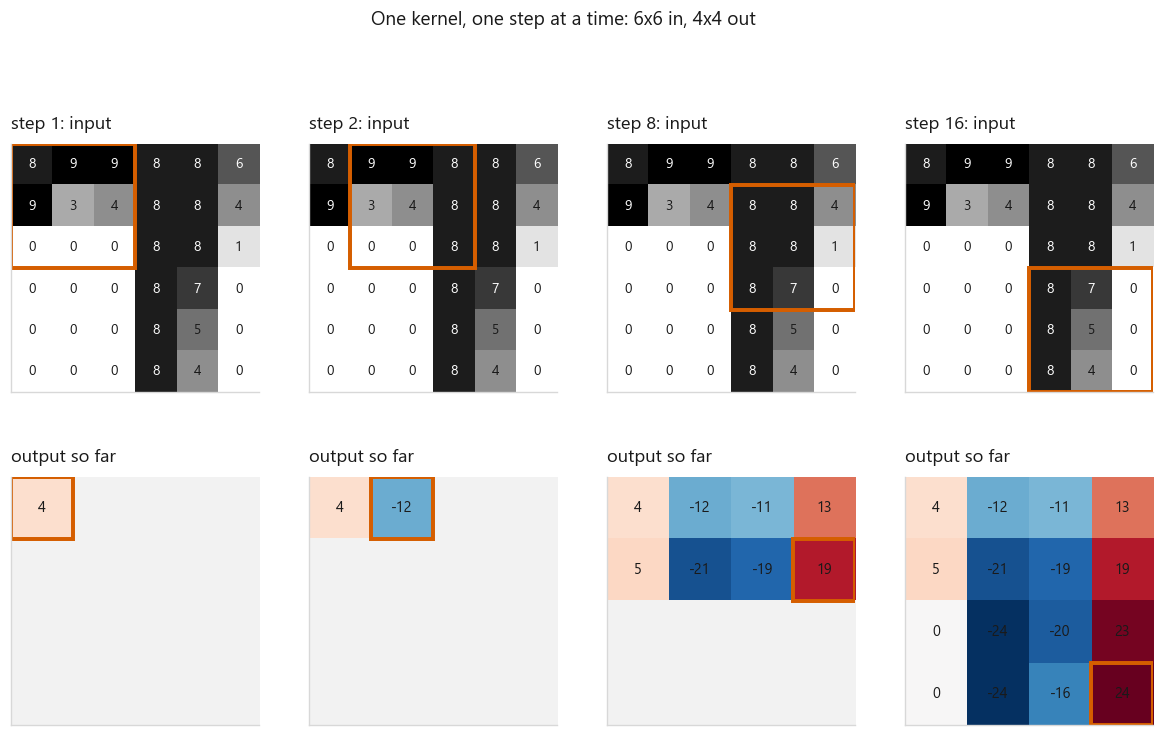

In [3]:
from matplotlib.patches import Rectangle

steps = [0, 1, 7, OUT_H * OUT_W - 1]
limit = np.abs(feature_map).max()
faded = plt.get_cmap("RdBu_r").copy()
faded.set_bad("#f2f2f2")   # positions the window has not reached yet

fig, axes = plt.subplots(2, len(steps), figsize=(13.4, 7.2))
for column, step in enumerate(steps):
    i, j = divmod(step, OUT_W)

    top = axes[0, column]
    top.imshow(patch, cmap="gray_r", vmin=0, vmax=9)
    for r in range(patch.shape[0]):
        for c in range(patch.shape[1]):
            top.text(c, r, f"{patch[r, c]:.0f}", ha="center", va="center", fontsize=9,
                     color="white" if patch[r, c] > 5 else style.INK)
    top.add_patch(Rectangle((j - 0.5, i - 0.5), 3, 3, fill=False,
                            edgecolor=style.HIGHLIGHT, linewidth=2.6))
    top.set_xticks([]); top.set_yticks([]); top.grid(False)
    style.title(top, f"step {step + 1}: input")

    order = np.arange(OUT_H * OUT_W).reshape(OUT_H, OUT_W)
    bottom = axes[1, column]
    bottom.imshow(np.where(order <= step, feature_map, np.nan),
                  cmap=faded, vmin=-limit, vmax=limit)
    for r in range(OUT_H):
        for c in range(OUT_W):
            if order[r, c] <= step:
                bottom.text(c, r, f"{feature_map[r, c]:.0f}", ha="center", va="center",
                            fontsize=9.5, color=style.INK)
    bottom.add_patch(Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                               edgecolor=style.HIGHLIGHT, linewidth=2.6))
    bottom.set_xticks([]); bottom.set_yticks([]); bottom.grid(False)
    style.title(bottom, "output so far")

fig.suptitle("One kernel, one step at a time: 6x6 in, 4x4 out",
             x=0.5, y=1.03, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-01-sliding-window.png")

print(f"the {patch.shape[0]}x{patch.shape[1]} patch became a "
      f"{OUT_H}x{OUT_W} map: the window cannot hang off the edge")

Two things are visible in that picture and both come back later. The output is
smaller than the input, because the window has to fit entirely inside. And the
output is large and positive where the patch goes bright-to-dark from left to
right, negative where it goes the other way, near zero on flat ground — that
kernel is a vertical edge detector, and I chose its nine numbers to make it one.

Nothing in the operation says where those nine numbers come from. Before anyone
trained anything, image processing had a stock of hand-designed kernels, and
running them side by side shows how much the same operation can do depending
only on what you put in the grid.

In [4]:
KERNELS = {
    "identity":   [[0, 0, 0], [0, 1, 0], [0, 0, 0]],
    "box blur":   [[1 / 9] * 3] * 3,
    "gaussian":   [[1 / 16, 2 / 16, 1 / 16],
                   [2 / 16, 4 / 16, 2 / 16],
                   [1 / 16, 2 / 16, 1 / 16]],
    "sharpen":    [[0, -1, 0], [-1, 5, -1], [0, -1, 0]],
    "sobel x":    [[1, 0, -1], [2, 0, -2], [1, 0, -1]],
    "sobel y":    [[1, 2, 1], [0, 0, 0], [-1, -2, -1]],
    "laplacian":  [[0, 1, 0], [1, -4, 1], [0, 1, 0]],
    "emboss":     [[-2, -1, 0], [-1, 1, 1], [0, 1, 2]],
}

batch = sample_image.unsqueeze(0)
outputs, rows = {}, []
for name, values in KERNELS.items():
    weight = torch.tensor(values, dtype=torch.float32).view(1, 1, 3, 3)
    result = F.conv2d(batch, weight, padding=1).squeeze().numpy()
    outputs[name] = result
    rows.append({"kernel": name, "weight sum": float(np.sum(values)),
                 "output mean": result.mean(), "output std": result.std()})

print(f"one {CLASSES[sample_label]}, eight kernels:")
print(pd.DataFrame(rows).round(3).to_string(index=False))

one sandal, eight kernels:
   kernel  weight sum  output mean  output std
 identity         1.0        0.204       0.353
 box blur         1.0        0.203       0.286
 gaussian         1.0        0.203       0.297
  sharpen         1.0        0.205       0.822
  sobel x         0.0       -0.001       1.239
  sobel y         0.0        0.000       1.133
laplacian         0.0       -0.002       0.568
   emboss         1.0        0.204       1.348


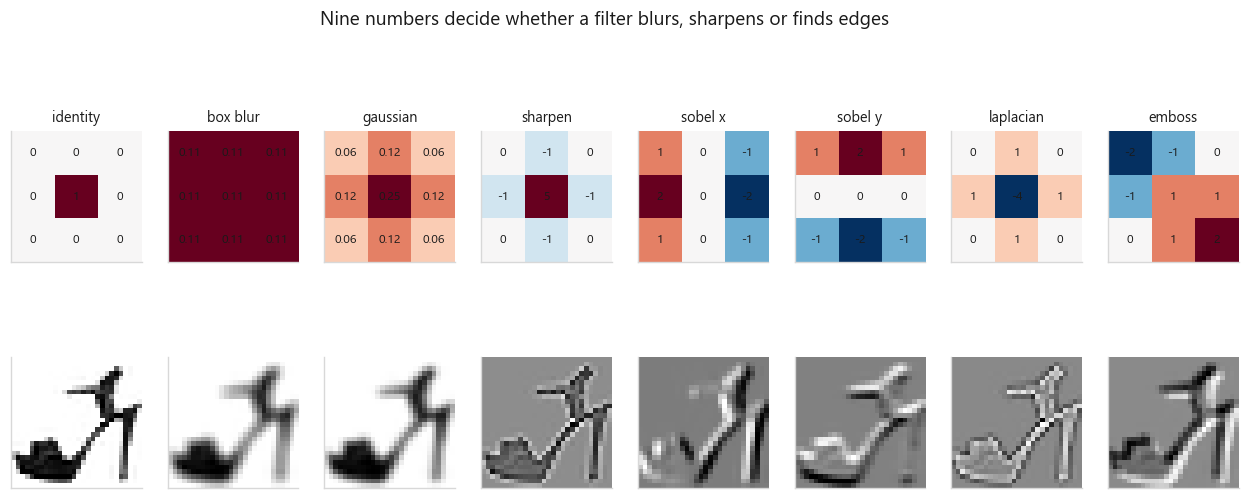

In [5]:
fig, axes = plt.subplots(2, len(KERNELS), figsize=(14.4, 4.9))
for column, (name, values) in enumerate(KERNELS.items()):
    grid = np.array(values, dtype=float)
    span = np.abs(grid).max()

    top = axes[0, column]
    top.imshow(grid, cmap="RdBu_r", vmin=-span, vmax=span)
    for r in range(3):
        for c in range(3):
            top.text(c, r, f"{np.round(grid[r, c], 2):g}", ha="center", va="center",
                     fontsize=8, color=style.INK)
    top.set_xticks([]); top.set_yticks([]); top.grid(False)
    top.set_title(name, fontsize=9.5, color=style.INK)

    bottom = axes[1, column]
    bottom.imshow(outputs[name], cmap="gray_r")
    bottom.set_xticks([]); bottom.set_yticks([]); bottom.grid(False)

fig.suptitle("Nine numbers decide whether a filter blurs, sharpens or finds edges",
             x=0.5, y=1.05, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-02-kernels.png")

The printed table separates the two families. Kernels whose weights sum to one
preserve average brightness, so their output still looks like the garment.
Kernels whose weights sum to zero cancel on flat regions and respond only where
something changes, so their output is dark everywhere except at boundaries.

In [08-02](../02-a-cnn-layer-by-layer/) the nine numbers stop being my choice and
become parameters. What comes out of training looks a lot like the third and
fourth columns here, which nobody asked for.

## 2. From scratch, checked against torch

The operation is a loop over output positions, and I would rather write that
loop once than take anyone's word for it. Padding, stride and dilation all fit
inside the same loop:

padding adds a border of zeros before the sliding starts; stride is how far the
window jumps between positions; dilation spreads the kernel taps apart so the
window covers more ground without holding more weights.

In [6]:
def conv2d_scratch(image, kernel, padding=0, stride=1, dilation=1):
    """One channel in, one channel out, written as the sliding window it is.

    Slow on purpose. The point is that every index is visible.
    """
    kh, kw = kernel.shape
    # dilation puts holes between the taps, so the window is wider than the kernel
    reach_h = dilation * (kh - 1) + 1
    reach_w = dilation * (kw - 1) + 1

    padded = np.pad(image, padding)
    out_h = (padded.shape[0] - reach_h) // stride + 1
    out_w = (padded.shape[1] - reach_w) // stride + 1

    out = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            top, left = i * stride, j * stride
            patch = padded[top:top + reach_h:dilation, left:left + reach_w:dilation]
            out[i, j] = (patch * kernel).sum()
    return out


rng = np.random.default_rng(SEED)
probe_image = rng.standard_normal((13, 17))          # float64 on purpose, so that
probe_kernel = rng.standard_normal((3, 3))           # "machine precision" means something

checks = []
for padding, stride, dilation in [(0, 1, 1), (1, 1, 1), (2, 1, 1), (0, 2, 1),
                                  (1, 2, 1), (0, 1, 2), (2, 3, 2), (3, 1, 3)]:
    mine = conv2d_scratch(probe_image, probe_kernel, padding, stride, dilation)
    theirs = F.conv2d(torch.from_numpy(probe_image)[None, None],
                      torch.from_numpy(probe_kernel)[None, None],
                      padding=padding, stride=stride, dilation=dilation)[0, 0].numpy()
    checks.append({"padding": padding, "stride": stride, "dilation": dilation,
                   "my shape": str(mine.shape), "torch shape": str(theirs.shape),
                   "max abs diff": np.abs(mine - theirs).max()})

checks = pd.DataFrame(checks)
print(checks.to_string(index=False, float_format=lambda v: f"{v:.2e}"))
print(f"\nlargest difference anywhere: {checks['max abs diff'].max():.3e}")
print(f"float64 machine epsilon:     {np.finfo(np.float64).eps:.3e}")

 padding  stride  dilation my shape torch shape  max abs diff
       0       1         1 (11, 15)    (11, 15)      1.33e-15
       1       1         1 (13, 17)    (13, 17)      1.33e-15
       2       1         1 (15, 19)    (15, 19)      1.33e-15
       0       2         1   (6, 8)      (6, 8)      8.88e-16
       1       2         1   (7, 9)      (7, 9)      8.88e-16
       0       1         2  (9, 13)     (9, 13)      9.16e-16
       2       3         2   (5, 6)      (5, 6)      8.88e-16
       3       1         3 (13, 17)    (13, 17)      8.88e-16

largest difference anywhere: 1.332e-15
float64 machine epsilon:     2.220e-16


The differences sit at the level of floating point rounding, which is the only
agreement worth claiming. It also confirms the unflipped convention: if torch
flipped the kernel and I did not, an asymmetric kernel like this one would
disagree loudly rather than at the sixteenth decimal.

Real layers have many channels, and a single **filter** is then an
`in_channels × k × k` block. It sees every input channel at once and produces
one output channel; a layer holds `out_channels` of those blocks. The sum runs
over channels as well as over the window.

In [7]:
def conv2d_multi(x, weight, bias, padding=0, stride=1):
    """x: (c_in, h, w). weight: (c_out, c_in, kh, kw). One bias per output channel."""
    c_out, c_in = weight.shape[0], weight.shape[1]
    planes = []
    for o in range(c_out):
        # every input channel contributes to every output channel, then they add
        total = sum(conv2d_scratch(x[c], weight[o, c], padding, stride)
                    for c in range(c_in))
        planes.append(total + bias[o])
    return np.stack(planes)


def conv2d_windows(x, weight, bias, padding=0, stride=1):
    """The same thing with the loop replaced by one contraction. This is the idea
    behind im2col, and roughly what a real library does before calling BLAS."""
    padded = np.pad(x, ((0, 0), (padding, padding), (padding, padding)))
    views = np.lib.stride_tricks.sliding_window_view(padded, weight.shape[2:], axis=(1, 2))
    views = views[:, ::stride, ::stride]              # (c_in, out_h, out_w, kh, kw)
    return np.einsum("cijmn,ocmn->oij", views, weight) + bias[:, None, None]


x = rng.standard_normal((4, 20, 24))
w = rng.standard_normal((6, 4, 3, 3))
b = rng.standard_normal(6)

started = time.perf_counter()
loops = conv2d_multi(x, w, b, padding=1, stride=2)
loop_seconds = time.perf_counter() - started

started = time.perf_counter()
vectorised = conv2d_windows(x, w, b, padding=1, stride=2)
window_seconds = time.perf_counter() - started

reference = F.conv2d(torch.from_numpy(x)[None], torch.from_numpy(w),
                     torch.from_numpy(b), padding=1, stride=2)[0].numpy()

print(f"output shape {loops.shape}, torch {reference.shape}")
print(f"loops    vs torch : {np.abs(loops - reference).max():.3e}")
print(f"windowed vs torch : {np.abs(vectorised - reference).max():.3e}")
print(f"loops {loop_seconds * 1e3:.1f} ms, windowed {window_seconds * 1e3:.1f} ms "
      f"({loop_seconds / window_seconds:.0f}x)")

output shape (6, 10, 12), torch (6, 10, 12)
loops    vs torch : 7.105e-15
windowed vs torch : 7.105e-15
loops 17.4 ms, windowed 0.6 ms (32x)


Both versions agree with the library. The second one refuses to write a Python
loop where a single tensor contraction will do, and the maths is unchanged. That
rewrite is why convolutions run at a sensible speed on real hardware.

## 3. The size arithmetic

Every shape question in a convolutional network comes out of one formula. For an
input of side $n$, kernel $k$, padding $p$, stride $s$ and dilation $d$:

$$\text{out} = \left\lfloor \frac{n + 2p - d(k-1) - 1}{s} \right\rfloor + 1$$

The $d(k-1)+1$ term is the reach of the kernel: how many input pixels the window
spans once the taps are spread apart. Subtract it from the padded input, divide
by how far you jump, add one for the starting position. That is the whole thing,
and the floor is where sizes quietly stop being what you expected.

In [8]:
def output_size(n, k, padding=0, stride=1, dilation=1):
    """The one formula. Every shape in the rest of this chapter comes from it."""
    return (n + 2 * padding - dilation * (k - 1) - 1) // stride + 1


cases = [(28, 3, 0, 1, 1), (28, 3, 1, 1, 1), (28, 5, 2, 1, 1), (28, 7, 3, 1, 1),
         (28, 3, 0, 2, 1), (28, 3, 1, 2, 1), (28, 2, 0, 2, 1), (28, 3, 1, 3, 1),
         (28, 3, 0, 1, 2), (32, 3, 0, 1, 4), (28, 4, 1, 1, 1), (28, 5, 0, 3, 2)]

rows = []
for n, k, p, s, d in cases:
    actual = F.conv2d(torch.zeros(1, 1, n, n), torch.zeros(1, 1, k, k),
                      padding=p, stride=s, dilation=d).shape[-1]
    rows.append({"n": n, "k": k, "p": p, "s": s, "d": d,
                 "reach": d * (k - 1) + 1,
                 "formula": output_size(n, k, p, s, d), "torch": actual})

shapes = pd.DataFrame(rows)
assert (shapes["formula"] == shapes["torch"]).all()
print(shapes.to_string(index=False))
print("\nformula and torch agree on every row")

 n  k  p  s  d  reach  formula  torch
28  3  0  1  1      3       26     26
28  3  1  1  1      3       28     28
28  5  2  1  1      5       28     28
28  7  3  1  1      7       28     28
28  3  0  2  1      3       13     13
28  3  1  2  1      3       14     14
28  2  0  2  1      2       14     14
28  3  1  3  1      3       10     10
28  3  0  1  2      5       24     24
32  3  0  1  4      9       24     24
28  4  1  1  1      4       27     27
28  5  0  3  2      9        7      7

formula and torch agree on every row


### Padding: same or valid

`valid` means no padding: only positions where the window fits entirely inside
count, so the map shrinks by the reach minus one on each axis, every layer.
`same` means pad enough that the output keeps the input size, which for stride 1
and odd $k$ works out to $p = (k-1)/2$ — one ring of zeros for a 3×3 kernel, two
for 5×5.

Odd kernel sizes are the convention for exactly this reason: they have a centre
pixel, so the padding is the same on both sides. An even kernel has to pad
unevenly, and torch does that silently.

The cost of shrinking is not obvious from one layer. Stack a few and it is.

In [9]:
for k in (3, 5, 7):
    same = F.conv2d(torch.zeros(1, 1, 28, 28), torch.zeros(1, 1, k, k), padding="same")
    valid = F.conv2d(torch.zeros(1, 1, 28, 28), torch.zeros(1, 1, k, k), padding="valid")
    print(f"{k}x{k} kernel on 28x28: same -> {tuple(same.shape[-2:])}, "
          f"valid -> {tuple(valid.shape[-2:])}, matching p = {(k - 1) // 2}")

even = F.conv2d(torch.zeros(1, 1, 28, 28), torch.zeros(1, 1, 4, 4), padding="same")
print(f"\n4x4 kernel with padding='same': {tuple(even.shape[-2:])} — torch pads 2 on one "
      f"side and 1 on the other")

try:
    F.conv2d(torch.zeros(1, 1, 28, 28), torch.zeros(1, 1, 3, 3), padding="same", stride=2)
except Exception as error:
    print(f"\npadding='same' with stride 2 -> {type(error).__name__}: {error}")

size, depth = 28, 0
while size >= 3:
    size = output_size(size, 3)
    depth += 1
print(f"\nstarting from 28x28, a 3x3 valid conv can be stacked {depth} times "
      f"before the map is {size}x{size}")

3x3 kernel on 28x28: same -> (28, 28), valid -> (26, 26), matching p = 1
5x5 kernel on 28x28: same -> (28, 28), valid -> (24, 24), matching p = 2
7x7 kernel on 28x28: same -> (28, 28), valid -> (22, 22), matching p = 3

4x4 kernel with padding='same': (28, 28) — torch pads 2 on one side and 1 on the other

padding='same' with stride 2 -> RuntimeError: padding='same' is not supported for strided convolutions

starting from 28x28, a 3x3 valid conv can be stacked 13 times before the map is 2x2


C:\Users\pilot\AppData\Local\Temp\ipykernel_20684\3324842028.py:7: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Convolution.cpp:1025.)
  even = F.conv2d(torch.zeros(1, 1, 28, 28), torch.zeros(1, 1, 4, 4), padding="same")


### Stride and dilation

Stride is downsampling built into the convolution: jump $s$ pixels between
window positions and the output side is divided by roughly $s$. Dilation leaves
the step at one but spreads the taps, so the window reaches further while the
weight count stays fixed. They pull in opposite directions on the output size
and in the same direction on how much input each output sees.

valid stack: [28, 26, 24, 22, 20, 18, 16, 14, 12, 10, 8, 6, 4, 2]
same stack:  [28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28]


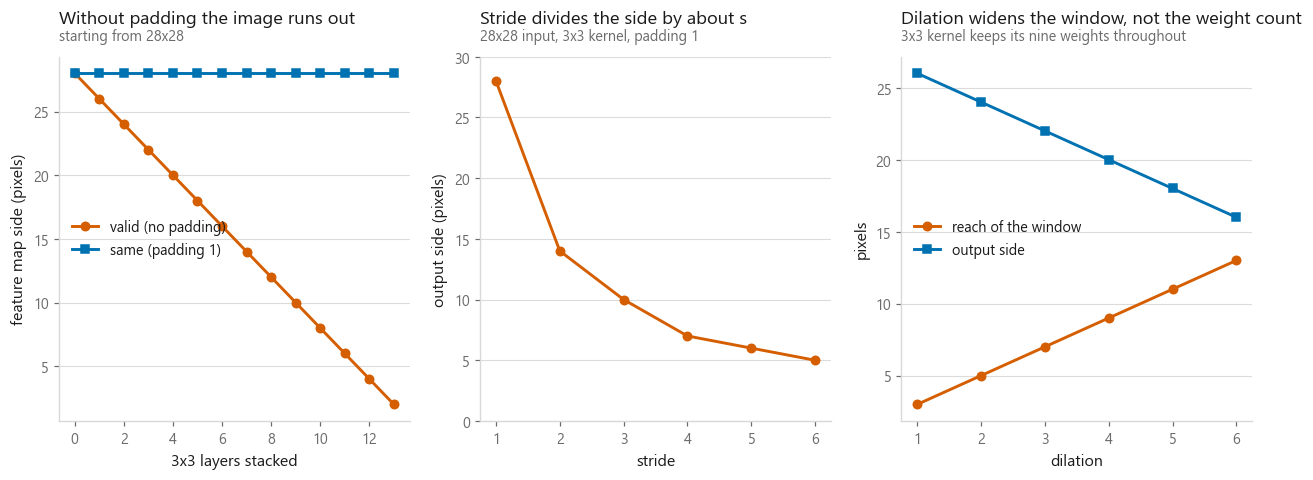

In [10]:
DEPTH = 13
valid_track = [28]
same_track = [28]
for _ in range(DEPTH):
    previous = valid_track[-1]
    # once the map is smaller than the kernel the layer cannot be applied at all
    valid_track.append(output_size(previous, 3) if previous >= 3 else 0)
    same_track.append(output_size(same_track[-1], 3, padding=1))

strides = range(1, 7)
stride_sizes = [output_size(28, 3, padding=1, stride=s) for s in strides]

dilations = range(1, 7)
reaches = [d * (3 - 1) + 1 for d in dilations]
dilated_sizes = [output_size(28, 3, dilation=d) for d in dilations]

fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.3))

axes[0].plot(range(DEPTH + 1), valid_track, marker=style.MARKERS[0],
             color=style.HIGHLIGHT, label="valid (no padding)")
axes[0].plot(range(DEPTH + 1), same_track, marker=style.MARKERS[1],
             color=style.PALETTE[0], label="same (padding 1)")
axes[0].set_xlabel("3x3 layers stacked")
axes[0].set_ylabel("feature map side (pixels)")
axes[0].legend(loc="center left")
style.title(axes[0], "Without padding the image runs out", "starting from 28x28")

axes[1].plot(list(strides), stride_sizes, marker=style.MARKERS[0], color=style.HIGHLIGHT)
axes[1].set_xlabel("stride")
axes[1].set_ylabel("output side (pixels)")
axes[1].set_ylim(0, 30)
style.title(axes[1], "Stride divides the side by about s", "28x28 input, 3x3 kernel, padding 1")

axes[2].plot(list(dilations), reaches, marker=style.MARKERS[0], color=style.HIGHLIGHT,
             label="reach of the window")
axes[2].plot(list(dilations), dilated_sizes, marker=style.MARKERS[1],
             color=style.PALETTE[0], label="output side")
axes[2].set_xlabel("dilation")
axes[2].set_ylabel("pixels")
axes[2].legend(loc="center left")
style.title(axes[2], "Dilation widens the window, not the weight count",
            "3x3 kernel keeps its nine weights throughout")

style.save(fig, FIG / "fig-03-size-arithmetic.png")

print(f"valid stack: {valid_track}")
print(f"same stack:  {same_track}")

The left panel is the practical reason `padding=1` appears on nearly every 3×3
layer in nearly every architecture. A deep network with no padding spends its
depth budget eating its own image, and it eats it from the border inwards, so
the pixels at the edges pass through fewer layers than the pixels in the middle.

### Channels, and how many parameters that is

A layer with `in_channels` inputs and `out_channels` outputs holds one
`in_channels × k × k` block per output channel, plus one bias each:

$$\text{parameters} = C_\text{in} \cdot C_\text{out} \cdot k \cdot k + C_\text{out}$$

The height and width of the image are absent from that expression, and that
absence is the entire economic argument for convolution.

In [11]:
layer = torch.nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
by_hand = 16 * 32 * 3 * 3 + 32
by_torch = sum(p.numel() for p in layer.parameters())
print(f"Conv2d(16, 32, 3): 16 * 32 * 3 * 3 + 32 = {by_hand:,}, torch reports {by_torch:,}")
print(f"  weight {tuple(layer.weight.shape)}, bias {tuple(layer.bias.shape)}")

rows = []
for c_in, c_out, k in [(1, 16, 3), (16, 32, 3), (32, 64, 3),
                       (3, 64, 7), (256, 256, 3), (256, 256, 1)]:
    reference = torch.nn.Conv2d(c_in, c_out, k)
    rows.append({"in": c_in, "out": c_out, "k": k,
                 "formula": c_in * c_out * k * k + c_out,
                 "torch": sum(p.numel() for p in reference.parameters())})
table = pd.DataFrame(rows)
assert (table["formula"] == table["torch"]).all()
print()
print(table.to_string(index=False))

print("\nthe same layer on three input sizes:")
with torch.no_grad():
    for n in (14, 64, 224):
        shape = tuple(layer(torch.zeros(1, 16, n, n)).shape)
        print(f"  {n:3d}x{n:<3d} -> {shape}, still {by_torch:,} parameters")

dense_equivalent = (16 * 14 * 14) * (32 * 14 * 14) + 32 * 14 * 14
print(f"\na dense layer mapping the same 16x14x14 tensor to 32x14x14 would need "
      f"{dense_equivalent:,}")
print(f"ratio: {dense_equivalent / by_torch:,.0f}x the convolution")

Conv2d(16, 32, 3): 16 * 32 * 3 * 3 + 32 = 4,640, torch reports 4,640
  weight (32, 16, 3, 3), bias (32,)

 in  out  k  formula  torch
  1   16  3      160    160
 16   32  3     4640   4640
 32   64  3    18496  18496
  3   64  7     9472   9472
256  256  3   590080 590080
256  256  1    65792  65792

the same layer on three input sizes:
   14x14  -> (1, 32, 14, 14), still 4,640 parameters
   64x64  -> (1, 32, 64, 64), still 4,640 parameters
  224x224 -> (1, 32, 224, 224), still 4,640 parameters

a dense layer mapping the same 16x14x14 tensor to 32x14x14 would need 19,675,264
ratio: 4,240x the convolution


The 1×1 row in that table looks like a mistake and is not. A 1×1 convolution
does no spatial mixing at all; it is a small dense layer applied identically at
every pixel, used to change the channel count cheaply. It shows up constantly
inside ResNet and Inception blocks.

## 4. Downsampling three ways

At some point the map has to get smaller: to cut computation, and to let later
layers see more of the image through the same size window. Three mechanisms are
in common use, and it is worth seeing them applied to the same input rather than
described.

**Max pooling** takes the largest value in each block. **Average pooling** takes
the mean. **A strided convolution** does a normal convolution but skips
positions, and unlike the other two it has weights, so it can learn what is
worth keeping.

In [12]:
image = sample_image.unsqueeze(0)
sobel_x = torch.tensor(KERNELS["sobel x"], dtype=torch.float32).view(1, 1, 3, 3)
gaussian = torch.tensor(KERNELS["gaussian"], dtype=torch.float32).view(1, 1, 3, 3)
edges = F.conv2d(image, sobel_x, padding=1).abs()

sources = {"raw image": image, "edge map": edges}
methods = {
    "max pool 2x2": lambda t: F.max_pool2d(t, 2),
    "average pool 2x2": lambda t: F.avg_pool2d(t, 2),
    "conv 3x3 stride 2": lambda t: F.conv2d(t, gaussian, stride=2, padding=1),
}

rows = []
for source_name, source in sources.items():
    for method_name, method in methods.items():
        with torch.no_grad():
            small = method(source)
        rows.append({"input": source_name, "method": method_name,
                     "shape": str(tuple(small.shape[-2:])),
                     "mean": small.mean().item(), "max": small.max().item(),
                     "peak kept": small.max().item() / source.max().item()})
print(pd.DataFrame(rows).round(3).to_string(index=False))

    input            method    shape  mean   max  peak kept
raw image      max pool 2x2 (14, 14) 0.305 1.000      1.000
raw image  average pool 2x2 (14, 14) 0.204 0.970      0.970
raw image conv 3x3 stride 2 (14, 14) 0.203 0.954      0.954
 edge map      max pool 2x2 (14, 14) 1.130 3.929      1.000
 edge map  average pool 2x2 (14, 14) 0.662 3.177      0.809
 edge map conv 3x3 stride 2 (14, 14) 0.652 2.985      0.760


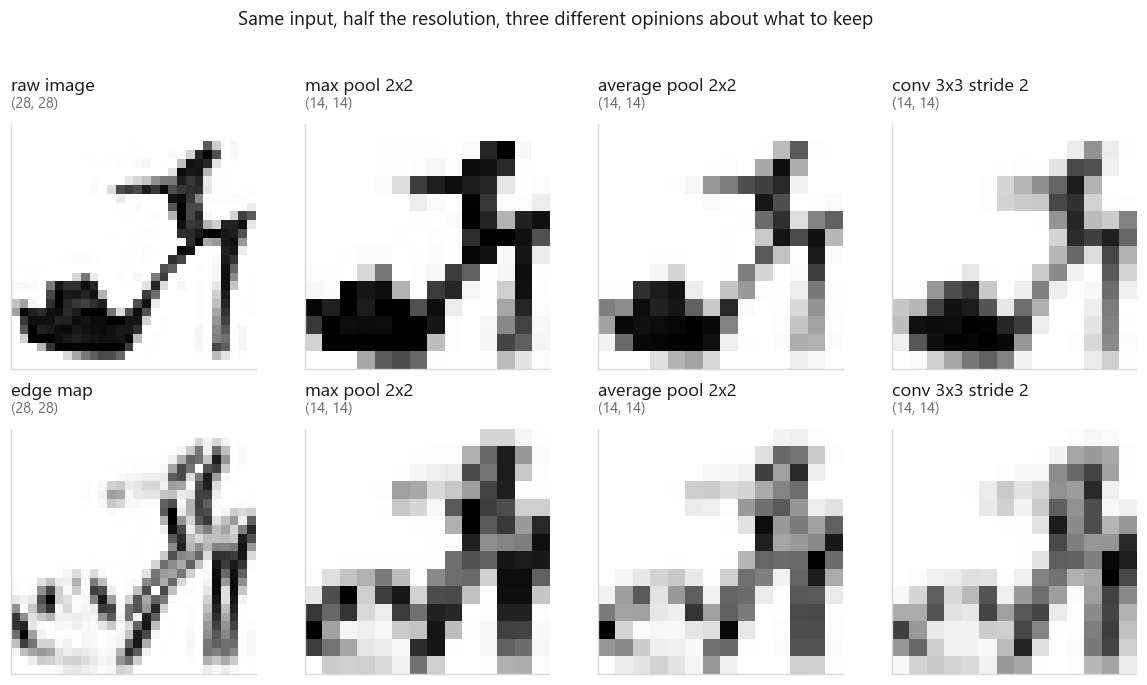

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(13.2, 6.6))
for row, (source_name, source) in enumerate(sources.items()):
    panel = axes[row, 0]
    panel.imshow(source[0, 0], cmap="gray_r")
    panel.set_xticks([]); panel.set_yticks([]); panel.grid(False)
    style.title(panel, source_name, f"{tuple(source.shape[-2:])}")

    for column, (method_name, method) in enumerate(methods.items(), start=1):
        with torch.no_grad():
            small = method(source)
        panel = axes[row, column]
        panel.imshow(small[0, 0], cmap="gray_r")
        panel.set_xticks([]); panel.set_yticks([]); panel.grid(False)
        style.title(panel, method_name, f"{tuple(small.shape[-2:])}")

fig.suptitle("Same input, half the resolution, three different opinions about what to keep",
             x=0.5, y=1.03, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-04-downsampling.png")

On the raw image the three look almost alike, which is why the second row is
there. On the edge map the difference is the point: max pooling keeps the peak
of every thin edge, so the outline survives at half resolution; average pooling
averages that peak with the three quieter neighbours sharing its block, so thin
structure fades. The printed "peak kept" column says the same thing in one
number per method.

None of the three is right in general. Max pooling is the traditional choice
for detecting whether a feature is present at all. Average pooling is gentler,
and it is what global pooling at the end of a modern network does. Strided
convolution is what several
recent architectures use in place of pooling entirely, on the argument that a
downsampling step with parameters can do better than a fixed rule — at the cost
of those parameters and the risk of aliasing.

## 5. Receptive field and translation equivariance

### How far back one output unit can see

One unit in the first layer sees a $k \times k$ patch of the input. One unit in
the second layer sees $k \times k$ first-layer units, each of which saw its own
patch, so it sees more. Stack enough layers and a single unit near the top
depends on most of the image. That footprint is the **receptive field**, and it
follows a two-line recurrence: track the field $r$ and the **jump** $j$, the
input distance between neighbouring units at the current layer.

$$r_\ell = r_{\ell-1} + d_\ell (k_\ell - 1) \cdot j_{\ell-1} \qquad
  j_\ell = j_{\ell-1} \cdot s_\ell$$

Stride does not widen the field much by itself; it widens every layer that comes
after, through the jump. That is why one pooling layer early on buys more
reach than the convolutions around it.

In [14]:
stack = [("conv 3x3", 3, 1, 1),
         ("conv 3x3", 3, 1, 1),
         ("pool 2x2 stride 2", 2, 2, 1),
         ("conv 3x3", 3, 1, 1),
         ("conv 3x3", 3, 1, 1),
         ("pool 2x2 stride 2", 2, 2, 1),
         ("conv 3x3", 3, 1, 1)]

field, jump, rows = 1, 1, []
for name, k, s, d in stack:
    field = field + d * (k - 1) * jump
    jump = jump * s
    rows.append({"layer": name, "k": k, "stride": s, "dilation": d,
                 "jump": jump, "receptive field": field})
growth = pd.DataFrame(rows)
print(growth.to_string(index=False))
print(f"\nafter this stack one output unit sees {field}x{field} input pixels")

plain = 1
layers_needed = 0
while plain < 28:
    plain += 2                       # a 3x3 stride-1 conv adds exactly 2, forever
    layers_needed += 1
print(f"with 3x3 stride-1 convs and no pooling it takes {layers_needed} layers "
      f"before one unit covers a whole 28x28 image (field {plain}x{plain})")

dilated_field, dilated_jump = 1, 1
for d in (1, 2, 4, 8):
    dilated_field += d * (3 - 1) * dilated_jump
print(f"four 3x3 convs with dilation 1, 2, 4, 8 reach {dilated_field}x{dilated_field} "
      f"using {4 * 9} weights")

            layer  k  stride  dilation  jump  receptive field
         conv 3x3  3       1         1     1                3
         conv 3x3  3       1         1     1                5
pool 2x2 stride 2  2       2         1     2                6
         conv 3x3  3       1         1     2               10
         conv 3x3  3       1         1     2               14
pool 2x2 stride 2  2       2         1     4               16
         conv 3x3  3       1         1     4               24

after this stack one output unit sees 24x24 input pixels
with 3x3 stride-1 convs and no pooling it takes 14 layers before one unit covers a whole 28x28 image (field 29x29)
four 3x3 convs with dilation 1, 2, 4, 8 reach 31x31 using 36 weights


The recurrence is easy to get wrong, so I check it the way I check everything
else: empirically. If I put a gradient of one on a single output unit and
backpropagate to the input, the pixels with a non-zero gradient are exactly the
pixels that unit depends on. The bounding box of that set is the receptive
field. I use average pooling for the probe because max pooling routes its
gradient to one winner and would undercount a footprint it genuinely has.

In [15]:
probe = torch.zeros(1, 1, 65, 65, dtype=torch.float64, requires_grad=True)
h = probe
for name, k, s, d in stack:
    if name.startswith("pool"):
        h = F.avg_pool2d(h, k, stride=s)
    else:
        h = F.conv2d(h, torch.ones(1, 1, k, k, dtype=torch.float64), stride=s, dilation=d)

centre = h.shape[-1] // 2
h[0, 0, centre, centre].backward()

touched = (probe.grad[0, 0] != 0)
rows_hit = touched.any(dim=1).nonzero().flatten()
cols_hit = touched.any(dim=0).nonzero().flatten()
measured_h = (rows_hit.max() - rows_hit.min() + 1).item()
measured_w = (cols_hit.max() - cols_hit.min() + 1).item()

print(f"formula says   : {field} x {field}")
print(f"gradient says  : {measured_h} x {measured_w}")
print(f"input pixels with a non-zero gradient: {int(touched.sum())} of {65 * 65}")
assert (measured_h, measured_w) == (field, field)

formula says   : 24 x 24
gradient says  : 24 x 24
input pixels with a non-zero gradient: 576 of 4225


### Translation equivariance

The other property is the one that makes convolution the right operation for
images. Because the same weights are applied at every position, moving the input
moves the output by the same amount and changes nothing else. A dense layer has
a separate weight for every pixel, so moving the input hands every weight a
different number and produces an unrelated answer.

I shift a garment sideways, run both through a fixed filter and a fixed dense
layer, then shift the convolutional feature map back and subtract.

In [16]:
SHIFT = 6


def shift_right(t, n):
    """Move the last axis n places right, filling the vacated strip with zeros."""
    out = torch.zeros_like(t)
    out[..., n:] = t[..., :-n]
    return out


base = sample_image
shifted = shift_right(base, SHIFT)

with torch.no_grad():
    map_base = F.conv2d(base.unsqueeze(0), sobel_x, padding=1)[0, 0]
    map_shifted = F.conv2d(shifted.unsqueeze(0), sobel_x, padding=1)[0, 0]
aligned = shift_right(map_base, SHIFT)

# the two borders are the only place the identity can break: one side was padded
# with zeros, the other had a strip of zeros pushed into it
interior = (aligned - map_shifted)[1:-1, SHIFT + 1:-1].abs().max()
print("conv: feature map of the shifted input vs the shifted feature map")
print(f"  max abs difference away from the borders : {interior.item():.3e}")
print(f"  max abs difference including borders     : "
      f"{(aligned - map_shifted).abs().max().item():.3e}")

torch.manual_seed(SEED)
dense = torch.nn.Linear(28 * 28, 32)
with torch.no_grad():
    dense_base = dense(base.reshape(1, -1))[0]
    dense_shifted = dense(shifted.reshape(1, -1))[0]

cosine = lambda a, b: F.cosine_similarity(a.flatten(), b.flatten(), dim=0).item()
print(f"\ncosine similarity between the two conv maps, unaligned : "
      f"{cosine(map_base, map_shifted):.3f}")
print(f"cosine similarity after shifting one back            : "
      f"{cosine(aligned, map_shifted):.3f}")
print(f"cosine similarity between the two dense outputs       : "
      f"{cosine(dense_base, dense_shifted):.3f}")
print(f"max abs change in a dense output unit                 : "
      f"{(dense_base - dense_shifted).abs().max().item():.3f}")

conv: feature map of the shifted input vs the shifted feature map
  max abs difference away from the borders : 0.000e+00
  max abs difference including borders     : 3.486e+00

cosine similarity between the two conv maps, unaligned : 0.008
cosine similarity after shifting one back            : 0.969
cosine similarity between the two dense outputs       : 0.313
max abs change in a dense output unit                 : 0.486


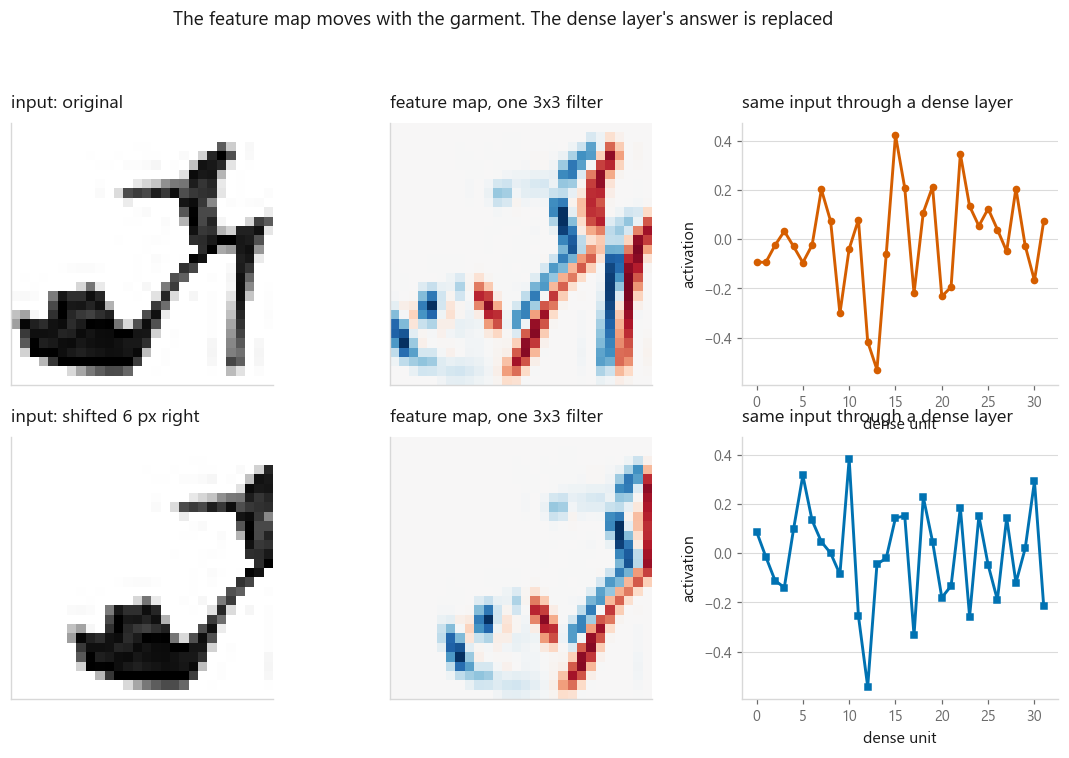

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(12.6, 6.8))
span = map_base.abs().max().item()
units = np.arange(dense_base.numel())
low = min(dense_base.min().item(), dense_shifted.min().item()) - 0.05
high = max(dense_base.max().item(), dense_shifted.max().item()) + 0.05

for row, (name, picture, feature, activations, colour) in enumerate([
    ("original", base, map_base, dense_base, style.HIGHLIGHT),
    (f"shifted {SHIFT} px right", shifted, map_shifted, dense_shifted, style.PALETTE[0]),
]):
    axes[row, 0].imshow(picture[0], cmap="gray_r")
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([]); axes[row, 0].grid(False)
    style.title(axes[row, 0], f"input: {name}")

    axes[row, 1].imshow(feature, cmap="RdBu_r", vmin=-span, vmax=span)
    axes[row, 1].set_xticks([]); axes[row, 1].set_yticks([]); axes[row, 1].grid(False)
    style.title(axes[row, 1], "feature map, one 3x3 filter")

    axes[row, 2].plot(units, activations.numpy(), marker=style.MARKERS[row],
                      color=colour, markersize=4)
    axes[row, 2].set_ylim(low, high)
    axes[row, 2].set_xlabel("dense unit")
    axes[row, 2].set_ylabel("activation")
    style.title(axes[row, 2], "same input through a dense layer")

fig.suptitle("The feature map moves with the garment. The dense layer's answer is replaced",
             x=0.5, y=1.03, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-05-equivariance.png")

The middle column is the whole idea in a picture. The two feature maps are the
same object at two positions, and once one is shifted back the printed
difference away from the borders is exactly zero, which is a stronger claim than
similarity. The right column is what happens without weight sharing: the dense
layer sees a different vector of 784 numbers and returns a different answer,
with no way to know the two pictures show the same garment. It would have to
learn that garment again at every offset, from examples it does not have.

Equivariance is not invariance. The feature map moved. Something later in the
network has to stop caring where it moved to, and pooling is the cheap version
of that: taking a maximum over a block makes the answer the same whether the
response landed on the left or the right of it. Stack a few and small shifts
stop mattering; that is the trade [08-02](../02-a-cnn-layer-by-layer/) makes.

## Cheat sheet

| | |
|---|---|
| **Output size** | `floor((n + 2p - d(k-1) - 1) / s) + 1`. Learn this one and you never guess a shape again |
| **Keeping the size** | Odd `k`, stride 1, `p = (k-1)//2`. That is what `padding='same'` does, and torch rejects it above stride 1 |
| **Parameters** | `in * out * k * k + out`. Image size does not appear, which is the point |
| **Reach** | `d(k-1) + 1`. Dilation widens the window without buying weights |
| **Downsampling** | Max pool keeps peaks, average pool smooths them away, strided conv learns what to keep and costs parameters |
| **Receptive field** | `r += d(k-1)*jump` then `jump *= stride`. Verify it by backpropagating to the input if it matters |
| **Watch out** | The libraries compute cross-correlation and call it convolution. No kernel flip anywhere, and nothing downstream cares |

## What to remember

1. A convolution is a sliding weighted sum. Everything else is bookkeeping about
   where the window goes.
2. The from-scratch loop matches `F.conv2d` to floating point noise across every
   combination of padding, stride and dilation. There is no hidden step.
3. One formula gives every output shape. Without padding the map shrinks each
   layer, and it shrinks from the border inwards.
4. Parameter count is `in * out * k * k + out` and does not depend on the image
   size. That is why a convolution scales to large inputs and a dense layer does not.
5. Max pooling, average pooling and strided convolution all halve the resolution
   and disagree about what survives — visibly so on an edge map.
6. The receptive field grows slowly through plain 3×3 convs and quickly through
   anything that raises the jump. Check it with a gradient if the answer matters.
7. Shift the input and the feature map shifts with it, exactly. A dense layer
   gets a new problem. That single property is why images are handled by
   convolutions.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [08-02 A CNN, layer by layer](../02-a-cnn-layer-by-layer/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#DeepLearning` `#Convolution` `#CNN` `#ComputerVision` `#PyTorch` `#NumPy`
`#FashionMNIST` `#MachineLearning` `#Python` `#MLTutorial` `#AI`